# Gradient Optimization

We import the usual culprits:

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import MCIntegrator, Telescope, hexshow

For better optimization, we also use the optax library:

In [2]:
import optax

## Import example telescope configuration:

As in all our tutorials we sample less values per facet to improve computation time, for better accuracy increase the amount of samples (ideally exponents of 2). For passing the gradients through mirror posititions, we also switch to STE (Straight-Through-Estimator) for the sensors.

In [3]:
%%time
telescope = Telescope.from_yaml('../../configs/HESS/CT3.yaml', MCIntegrator(128), key = jax.random.key(42))
telescope = telescope.apply_roughness(24).with_ste(sensor_idx=0)

CPU times: user 4.25 s, sys: 756 ms, total: 5.01 s
Wall time: 5.51 s


## Create truth telescope configuration
We create a misaligned truth to which we try to fit. We do this by misaligning the mirrors:

In [4]:
tel_truth = telescope.apply_misalignment_to_group(
        group_idx=0, sigma_h=20, sigma_v=20, key=jax.random.key(42)
    )

### Compare initial states
We can look at the difference in bokeh images between misaligned and aligned telescope. We also add 10% relative noise to the truth image to approximate an instrument error.

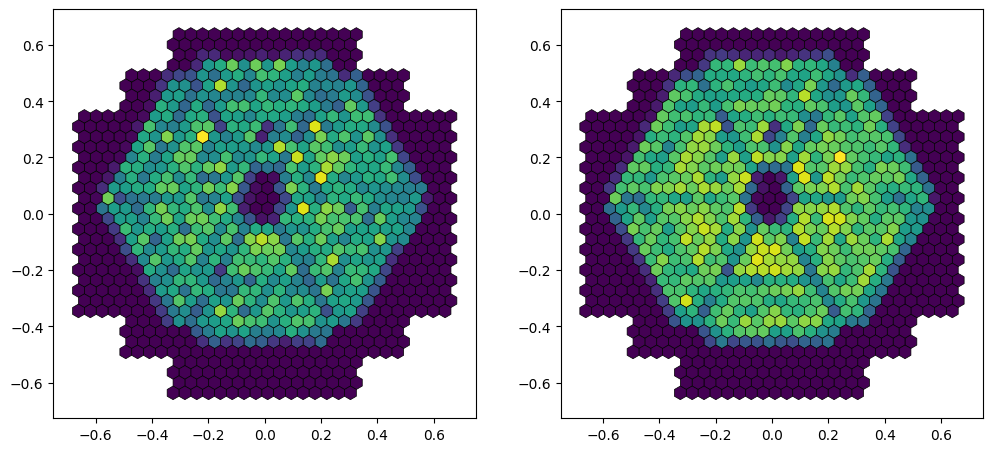

In [5]:
N_points = 1

key = jax.random.key(45)
key1, key2 = jax.random.split(key)

x = jax.random.uniform(key1, N_points, minval=-1, maxval=1)
y = jax.random.uniform(key2, N_points, minval=-1, maxval=1)
z = jnp.ones(N_points) * 200

points = jnp.array([x,y,z]).T
f_points = jnp.ones(len(points))

image_truth = tel_truth.render(points, f_points, source_type='point', sensor_idx=0)
image_tel = telescope.render(points, f_points, source_type='point', sensor_idx=0)

# Adding 10% relative noise to truth image:
image_truth = image_truth * (1 + 0.1 * jax.random.normal(jax.random.key(666), image_truth.shape))

fig, ax = plt.subplots(ncols=2, figsize=(12,6))
ax_hex = hexshow(image_truth, tel_truth.sensors[0], ax=ax[0])
ax_lid = hexshow(image_tel, telescope.sensors[0], ax=ax[1])

## Fit mirror alignment via gradient descent on Bokeh data

We can try and recover the individual mirror positions via gradient descent, but at this distance the individual facets are not really visible, so it might be difficult for the fit to converge using the science camera and a single image:

In [6]:
def mse_loss(img1, img2):
    return jnp.mean((img1 - img2)**2)

@eqx.filter_jit
def loss_fn(trainable, static, target_img):
    tel = eqx.combine(trainable, static)
    pred_img = tel.render(points, f_points, source_type='point', sensor_idx=0)
    return mse_loss(pred_img, target_img)

filter_spec = jax.tree.map(lambda _: False, telescope)
filter_spec = eqx.tree_at(
    lambda t: t.mirror_groups[0].rotations,
    filter_spec,
    replace=True
)

trainable, static = eqx.partition(telescope, filter_spec)

opt = optax.nadam(1e-4)
opt_state = opt.init(trainable)

@eqx.filter_jit
def step(trainable, opt_state, static, target):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(trainable, static, target)
    updates, opt_state = opt.update(grads, opt_state, trainable)
    trainable = eqx.apply_updates(trainable, updates)
    return trainable, opt_state, loss

In [7]:
for i in range(1000):
    trainable, opt_state, loss = step(trainable, opt_state, static, image_truth)
    if i % 100 == 0:
        print(f"{i}: {loss:.6f}")

# Reconstruct fitted telescope
telescope_fitted = eqx.combine(trainable, static)

0: 0.000508
100: 0.000083
200: 0.000046
300: 0.000037
400: 0.000036
500: 0.000036
600: 0.000032
700: 0.000028
800: 0.000025
900: 0.000027


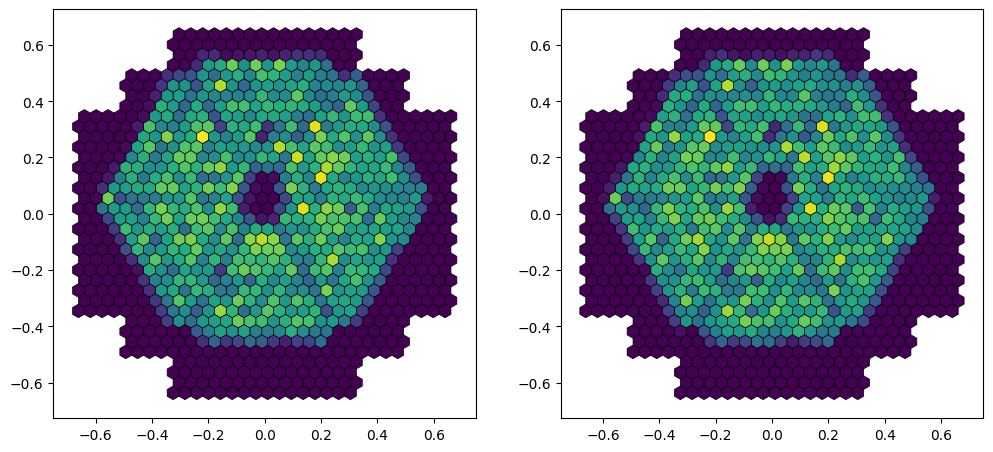

In [8]:
image_fitted = telescope_fitted.render(points, f_points, source_type='point', sensor_idx=0).block_until_ready()

fig, ax = plt.subplots(ncols=2, figsize=(12,6))
ax_hex = hexshow(image_truth, telescope.sensors[0], ax=ax[0])
ax_lid = hexshow(image_fitted, telescope_fitted.sensors[0], ax=ax[1])

While the image matches, we can see that the mirror positions are not very well determined. This is probably caused because of the high degeneracy at this Bokeh distance, where multiple mirror positions can create the same Bokeh pattern.

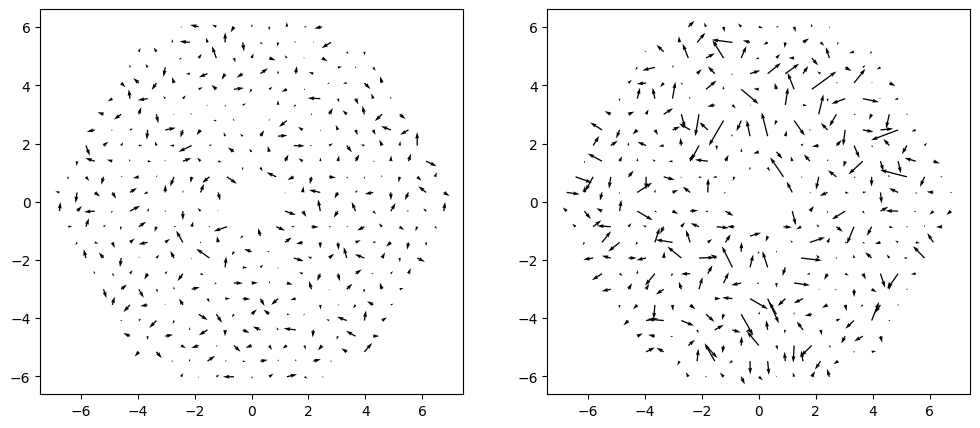

In [9]:
m_pos = telescope.mirror_groups[0].positions[:,:2]

delta_start = telescope.mirror_groups[0].rotations[:,:2]-tel_truth.mirror_groups[0].rotations[:,:2]
delta_end = telescope_fitted.mirror_groups[0].rotations[:,:2]-tel_truth.mirror_groups[0].rotations[:,:2]

fig, ax = plt.subplots(ncols=2, figsize=(12,5))
ax[0].quiver(m_pos[:,0], m_pos[:,1], 30*delta_start[:,0], 30*delta_start[:,1], angles='xy', scale_units='xy', scale=1)
ax[1].quiver(m_pos[:,0], m_pos[:,1], 30*delta_end[:,0], 30*delta_end[:,1], angles='xy', scale_units='xy', scale=1)

## Alignment via Bokeh array

Instead of using a single Bokeh image at a distance of 200m, we can use a closer array at 60m of multiple bokeh sources and fit them all at the same time to reconstruct the mirror positions:

In [10]:
N_side = 5
z_value = 60.0

x1d = jnp.linspace(-5, 5, N_side)
y1d = jnp.linspace(-5, 5, N_side)

X, Y = jnp.meshgrid(x1d, y1d, indexing="ij")

x = X.ravel()
y = Y.ravel()
z = jnp.full_like(x, z_value)

points = jnp.stack([x, y, z], axis=1)

f_points = jnp.ones(points.shape[0])*1000

We can render all the truths at once using the response matrix render option:

In [11]:
from iactrace.core.render import render_response_matrix

rm_truth = render_response_matrix(tel_truth, points, f_points, source_type='point', sensor_idx=0)

# Adding 10% relative noise to truth matrix:
rm_truth = rm_truth * (1 + 0.1 * jax.random.normal(jax.random.key(666), rm_truth.shape))

We now do the same thing as above to fit our parameters, just over all images at once instead of in a row:

In [12]:
@eqx.filter_jit
def loss_fn_rm(trainable, static, target_img):
    tel = eqx.combine(trainable, static)
    pred_img = render_response_matrix(tel, points, f_points, source_type='point', sensor_idx=0)
    return mse_loss(pred_img, target_img)

trainable, static = eqx.partition(telescope, filter_spec)

opt = optax.nadam(1e-4)
opt_state = opt.init(trainable)

@eqx.filter_jit
def step(trainable, opt_state, static, target):
    loss, grads = eqx.filter_value_and_grad(loss_fn_rm)(trainable, static, target)
    updates, opt_state = opt.update(grads, opt_state, trainable)
    trainable = eqx.apply_updates(trainable, updates)
    return trainable, opt_state, loss

In [13]:
for i in range(300):
    trainable, opt_state, loss = step(trainable, opt_state, static, rm_truth)
    if i % 100 == 0:
        print(f"{i}: {loss:.6f}")

# Reconstruct fitted telescope
telescope_fitted = eqx.combine(trainable, static)

0: 9.995541
100: 5.817142
200: 5.811924


The closer positions enable more accurate reconstructions:

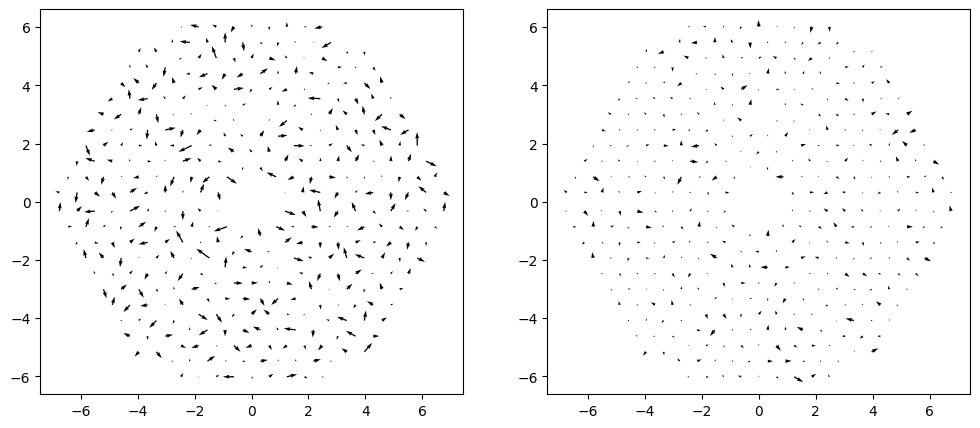

In [14]:
m_pos = telescope.mirror_groups[0].positions[:,:2]

delta_start = telescope.mirror_groups[0].rotations[:,:2]-tel_truth.mirror_groups[0].rotations[:,:2]
delta_end = telescope_fitted.mirror_groups[0].rotations[:,:2]-tel_truth.mirror_groups[0].rotations[:,:2]

fig, ax = plt.subplots(ncols=2, figsize=(12,5))
ax[0].quiver(m_pos[:,0], m_pos[:,1], 30*delta_start[:,0], 30*delta_start[:,1], angles='xy', scale_units='xy', scale=1)
ax[1].quiver(m_pos[:,0], m_pos[:,1], 30*delta_end[:,0], 30*delta_end[:,1], angles='xy', scale_units='xy', scale=1)

## Conclusion
The method shows promise, but a few steps are missing:
- Position of the point source are taken as truth, but they normally should be included in the fit as nuisance
- Flatfielding errors can cause this method to fail, since it is somewhat degenerate. Ideally these are also added as a nuisance parameter with prior restriction from other measurements.
- Individual mirror reflectivities also need to be adjusted at the same time.
- The time computation time will be higher when comparing to actual data, since the sampling might need to be increased.

This notebook is just meant as a proof of the concept.